<a href="https://colab.research.google.com/github/EzinneUfondu/Big-Data-/blob/main/customer_behaviour.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

# Import data

In [2]:
customer= pd.read_csv('/customer_events_lab.csv')
customer.head(10)

,event_time,customer_id,country,channel,device,category,action,price,quantity,discount,payment_status,delivery_minutes,rating,returned,revenue
0,2026-04-01 00:10:00,C00333,Ireland,physical_store,pos_terminal,home,purchase,48.83,2,10,paid,62.0,NaN,False,87.66
1,2026-04-01 00:15:00,C00207,Germany,web,android,beauty,review,41.95,0,0,not_applicable,NaN,4.0,False,0.00
2,2026-04-01 00:22:00,C00654,Germany,physical_store,pos_terminal,fashion,add_to_cart,30.89,0,0,not_applicable,NaN,NaN,False,0.00
3,2026-04-01 00:55:00,C00659,Ireland,physical_store,pos_terminal,grocery,return,11.86,1,0,not_applicable,NaN,NaN,True,11.86
4,2026-04-01 01:01:00,C00854,Sweden,web,android,grocery,purchase,15.87,1,10,paid,44.0,NaN,False,5.87
5,2026-04-01 01:11:00,C00550,Germany,physical_store,pos_terminal,electronics,view,97.20,0,0,not_applicable,NaN,NaN,False,0.00
6,2026-04-01 01:13:00,C00172,Sweden,web,android,sports,purchase,149.44,2,0,paid,29.0,NaN,False,298.88
7,2026-04-01 01:25:00,C00893,Germany,mobile_app,ios,fashion,view,77.51,0,0,not_applicable,NaN,NaN,False,0.00
8,2026-04-01 01:46:00,C00130,Germany,mobile_app,desktop,beauty,view,15.06,0,0,not_applicable,NaN,NaN,False,0.00
9,2026-04-01 01:47:00,C00313,United Kingdom,physical_store,pos_terminal,books,add_to_cart,12.61,0,0,not_applicable,NaN,NaN,False,0.00


In [3]:
customer.columns

Index(['event_time', 'customer_id', 'country', 'channel', 'device', 'category',
       'action', 'price', 'quantity', 'discount', 'payment_status',
       'delivery_minutes', 'rating', 'returned', 'revenue'],
      dtype='object')

# Columns and rows

In [4]:
customer.shape

(5000, 15)

# Number of counries

In [5]:
customer['country'].unique()

array(['Ireland', 'Germany', 'Sweden', 'United Kingdom', 'Netherlands',
       'France', nan], dtype=object)

# Channels

In [6]:
customer['channel'].unique()

array(['physical_store', 'web', 'mobile_app', 'partner_marketplace'],
      dtype=object)

# Category

In [7]:
customer['category'].unique()

array(['home', 'beauty', 'fashion', 'grocery', 'electronics', 'sports',
       'books'], dtype=object)

# Customer actions

In [8]:
customer['action'].unique()

array(['purchase', 'review', 'add_to_cart', 'return', 'view'],
      dtype=object)

Task 2: Data quality check

## Missing countries

In [9]:
customer['country'].isnull().sum()

np.int64(75)

## Missing Data accross all columns

In [10]:
customer.isnull().sum()

,0
event_time,0
customer_id,0
country,75
channel,0
device,100
category,0
action,0
price,0
quantity,0
discount,0


## Missing values are normal when action is not review
missing delivery_minutes is normal when action is not purchase.

#

## Channel with Highest total revenue

In [11]:
channel_revenue = customer.groupby('channel')['revenue'].sum()
highest_channel = channel_revenue.idxmax()
highest_revenue =channel_revenue.max()
print(highest_channel)
print (highest_revenue)

mobile_app
61258.22


##Bar Chart Representation

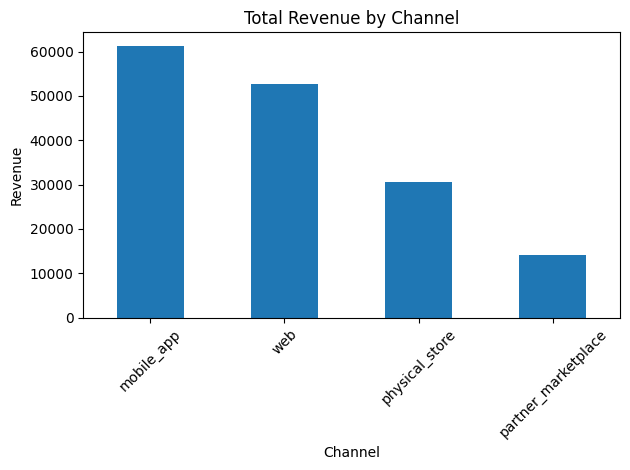

In [28]:
channel_revenue = customer.groupby('channel')['revenue'].sum().sort_values(ascending=False)


channel_revenue.plot(kind='bar')
plt.title('Total Revenue by Channel')
plt.xlabel('Channel')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.tight_layout()

### Which product category gives the highest total revenue

In [12]:
category_revenue = customer.groupby('category')['revenue'].sum()
highest_category = category_revenue.idxmax()
highest_revenue =category_revenue.max()
print(highest_category)
print (highest_revenue)

electronics
65616.94


## Country with highest number of customer events

In [13]:
customer['country'].value_counts()

,count
country,
Germany,2067
United Kingdom,808
Sweden,584
France,525
Netherlands,513
Ireland,428


### Bar Chart Representation:

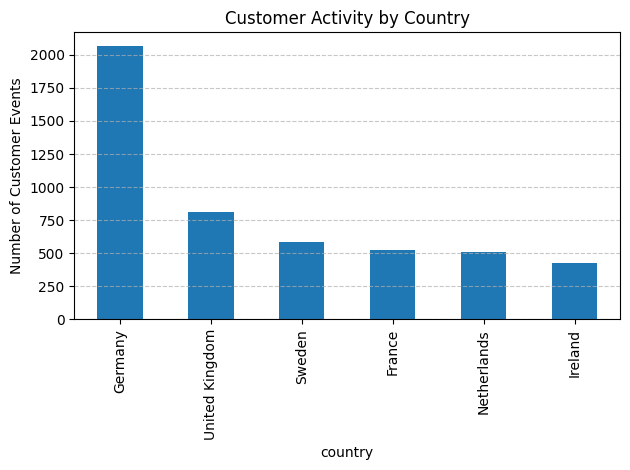

In [21]:
import matplotlib.pyplot as plt
country_events = customer['country'].value_counts()

country_events.plot(kind='bar')
plt.title('Customer Activity by Country')
plt.xlabel('country')
plt.ylabel('Number of Customer Events')
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)

## Channel with the slowest average delivery time

In [15]:
customer.groupby('channel')['delivery_minutes'].mean().sort_values(ascending=False)

,delivery_minutes
channel,
partner_marketplace,60.529762
web,54.965714
mobile_app,54.643312
physical_store,54.377301


In [16]:
customer.columns

Index(['event_time', 'customer_id', 'country', 'channel', 'device', 'category',
       'action', 'price', 'quantity', 'discount', 'payment_status',
       'delivery_minutes', 'rating', 'returned', 'revenue'],
      dtype='object')

## category with highest average rating?

In [17]:
customer.groupby('category')['rating'].mean().sort_values(ascending=False)

,rating
category,
grocery,3.588235
home,3.569231
sports,3.462963
beauty,3.459016
fashion,3.346154
electronics,3.297872
books,3.250000


# Business Insights

### Findings
1. The Mobile App channel generated the highest total revenue at 61,258.22 indicating that that customers appear to prefer purchasing through the mobile app.
--The app may offer a smoother shopping experience, better promotions, or higher customer engagement than other channels.

2. Electronics generated the highest total revenue at 65,616, indicating that Electronics products are likely high-value purchases and a major revenue driver.

3. Germany recorded 2,087 customer events, far ahead of the UK (808) and Ireland (428) indicating that Germany is clearly the company’s strongest market but the gap is so large that Germany may account for a disproportionately large share of engagement and sales.

4. Partner Marketplace recorded the slowest average delivery time at 60.52. This indicates potential inefficiencies in fulfilment of logistics and those inefficiencies can negatively affect customer satisfaction and repeat purchases.

5. Grocery had the highest average rating (3.58) and Books had the lowest average rating (3.25) indicating that customer satisfaction appears fairly consistent across categories.


## Business Actions
1. Analyze what features drive purchases and replicate them across other channels. for example: discounts, redeemable points, balanced inventory.
--Continue investing in the mobile app experience.

2. Prioritize inventory management for Electronics.
--We can also identify top-selling electronics products for further investment.

3. We should focus customer retention and marketing efforts on Germany.
-- Investigate why engagement is much lower in other countries.
-- Consider localized campaigns in the UK and Ireland to close the gap.

4. Review logistics performance for marketplace partners.
-- Monitor whether delayed deliveries correlate with lower ratings or higher cancellations.

5. Since rating differences are small, prioritize operational improvements (such as delivery speed) over category-specific quality concerns.

## Data Pipeline

┌─────────────────────┐
│ Customer Activity   │
└──────────┬──────────┘
           ↓
┌─────────────────────┐
│ CSV / Database      │
└──────────┬──────────┘
           ↓
┌─────────────────────┐
│ Anonymize IDs       │
└──────────┬──────────┘
           ↓
┌─────────────────────┐
│ Data Cleaning       │
└──────────┬──────────┘
           ↓
┌─────────────────────┐
│ Data Analysis       │
└──────────┬──────────┘
           ↓
┌─────────────────────┐
│ Dashboard           │
└──────────┬──────────┘
           ↓
┌─────────────────────┐
│ Business Decision   │
└─────────────────────┘

Governance Rule: Customer IDs are anonymized before analysis to protect customer privacy and comply with data protection regulations.